# Robustness Experiments: Explanation Stability under Data Degradation

This notebook is the extension's main experiment file. It does not re-run
or modify the original `ep_prediction_model.ipynb` baseline notebook, it
loads the already-fitted, already-validated pipelines saved by
`reproduce_and_save_rf_baseline.py` (RF), and uses `degradation.py`,
`experiment_utils.py`, and `shap_stability.py` to run the actual robustness
experiments.

Before running this notebook, confirm these files exist in `./artifacts/`:
- `com2_pipeline.joblib`, `com2_data_splits.joblib`, `com2_metadata.joblib`
- `rf_pipeline.joblib`, `rf_metadata.joblib`


## 1. Setup: imports and loading saved artifacts

In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib

from degradation import (
    inject_missing_mcar, inject_missing_mnar, inject_noise, inject_corruption
)
from experiment_utils import make_seeds, bootstrap_ci, bootstrap_diff_ci, run_repeated, save_results
from shap_stability import compute_shap_values, stability_report

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

ARTIFACT_DIR = "./artifacts"
RESULTS_DIR = "./results"


In [2]:
# Load the fitted pipelines + COM-2's data splits (RF was fit on the
# identical split, so we reuse the same X_test/y_test for both models).
xgb_pipeline = joblib.load(f"{ARTIFACT_DIR}/com2_pipeline.joblib")
xgb_metadata = joblib.load(f"{ARTIFACT_DIR}/com2_metadata.joblib")
data_splits = joblib.load(f"{ARTIFACT_DIR}/com2_data_splits.joblib")

rf_pipeline = joblib.load(f"{ARTIFACT_DIR}/rf_pipeline.joblib")
rf_metadata = joblib.load(f"{ARTIFACT_DIR}/rf_metadata.joblib")

X_test = data_splits["X_test"]
y_test = data_splits["y_test"]

XGB_THRESHOLD = xgb_metadata["threshold"]   # 0.45, per the baseline paper
RF_THRESHOLD = rf_metadata["threshold"]      # 0.5, default

print("X_test shape:", X_test.shape)
print("XGBoost threshold:", XGB_THRESHOLD, "| RF threshold:", RF_THRESHOLD)
assert X_test.shape[1] == 20, "X_test does not have the expected 20 COM-2 features - check artifacts."


X_test shape: (2643, 20)
XGBoost threshold: 0.45 | RF threshold: 0.5


## 2. Configuration

In [3]:
N_REPEATS = 50         
BASE_SEED = 2026
SHAP_SAMPLE_SIZE = 100  # matches the baseline paper's own SHAP sampling choice
TOP_K = 5               # for Jaccard top-k overlap

MCAR_LEVELS = [0.05, 0.10, 0.20, 0.30]
NOISE_LEVELS = [0.05, 0.10, 0.20, 0.30]   # std_frac
CORRUPTION_LEVELS = [0.05, 0.10, 0.20, 0.30]
MNAR_CONFIG = {"target_col": "HYEARGRx", "p_high": 0.40, "p_low": 0.05}
NOISE_COLUMNS = ["HYEARGRx", "FloorArea"]
CORRUPTION_COLUMNS = ["tenure2", "fuelx", "DWtype"]

MODELS = {
    "XGBoost": {"pipeline": xgb_pipeline, "threshold": XGB_THRESHOLD},
    "RandomForest": {"pipeline": rf_pipeline, "threshold": RF_THRESHOLD},
}


## 3. Core per-repeat evaluation function

This is the function `run_repeated()` (from `experiment_utils.py`) calls
once per seed. It: degrades a fresh copy of `X_test`, computes standard
performance metrics at the model's threshold, computes SHAP on both the
clean and degraded data (same 100 households each time), and returns a
flat dict of everything, performance + stability, for that one repeat.

In [4]:
# Pre-compute clean SHAP values once per model
print("Computing clean-data SHAP baseline for each model (one-time cost)...")
clean_shap = {}
for model_name, cfg in MODELS.items():
    result = compute_shap_values(cfg["pipeline"], X_test, sample_size=SHAP_SAMPLE_SIZE)
    clean_shap[model_name] = result
    print(f"  {model_name}: SHAP shape {result['shap_values'].shape}")


Computing clean-data SHAP baseline for each model (one-time cost)...
  XGBoost: SHAP shape (100, 20)
  RandomForest: SHAP shape (100, 20)


In [5]:
def evaluate_performance(pipeline, threshold, X, y):
    probs = pipeline.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y, preds),
        "balanced_accuracy": balanced_accuracy_score(y, preds),
        "precision": precision_score(y, preds, zero_division=0),
        "recall": recall_score(y, preds, zero_division=0),
        "f1": f1_score(y, preds, zero_division=0),
        "roc_auc": roc_auc_score(y, probs),
    }


def make_run_once_fn(model_name, degrade_fn):
    """
    Returns a function suitable for experiment_utils.run_repeated(): given a
    seed, degrades X_test using `degrade_fn`, evaluates performance, computes
    SHAP on the degraded data (same 100 households as the clean baseline),
    and returns performance + stability metrics for that one repeat.
    """
    pipeline = MODELS[model_name]["pipeline"]
    threshold = MODELS[model_name]["threshold"]
    clean_result = clean_shap[model_name]

    def run_once(seed):
        X_degraded = degrade_fn(X_test, seed)

        perf = evaluate_performance(pipeline, threshold, X_degraded, y_test)

        degraded_result = compute_shap_values(
            pipeline, X_degraded, sample_size=SHAP_SAMPLE_SIZE
        )
        stability = stability_report(
            clean_result["shap_values"],
            degraded_result["shap_values"],
            clean_result["feature_names"],
            k=TOP_K,
        )

        return {**perf, **stability}

    return run_once


## 4. Degradation condition definitions

Each entry pairs a condition name with a function that
degrades `X` given a `seed`. These are what actually get looped over.

In [6]:
def build_conditions():
    conditions = []

    for level in MCAR_LEVELS:
        conditions.append((
            "MCAR", level,
            lambda X, seed, lvl=level: inject_missing_mcar(X, pct=lvl, random_state=seed)
        ))

    # MNAR: severity here scales p_high while keeping p_low fixed, so higher
    # "severity" means a larger gap between renters' and owners' missingness
    # rates, not just a uniform shift.
    for level in MCAR_LEVELS:
        p_high = min(MNAR_CONFIG["p_high"] * (level / 0.20), 0.95)
        conditions.append((
            "MNAR", level,
            lambda X, seed, ph=p_high: inject_missing_mnar(
                X, target_col=MNAR_CONFIG["target_col"],
                condition=(X["tenure4x"] == 2),
                p_high=ph, p_low=MNAR_CONFIG["p_low"], random_state=seed,
            )
        ))

    for level in NOISE_LEVELS:
        conditions.append((
            "Noise", level,
            lambda X, seed, lvl=level: inject_noise(
                X, columns=NOISE_COLUMNS, std_frac=lvl, random_state=seed
            )
        ))

    for level in CORRUPTION_LEVELS:
        conditions.append((
            "Corruption", level,
            lambda X, seed, lvl=level: inject_corruption(
                X, columns=CORRUPTION_COLUMNS, pct=lvl, random_state=seed
            )
        ))

    return conditions

conditions = build_conditions()
print(f"Total conditions: {len(conditions)} (degradation types x severity levels)")
for name, level, _ in conditions:
    print(f"  {name} @ {level}")


Total conditions: 16 (degradation types x severity levels)
  MCAR @ 0.05
  MCAR @ 0.1
  MCAR @ 0.2
  MCAR @ 0.3
  MNAR @ 0.05
  MNAR @ 0.1
  MNAR @ 0.2
  MNAR @ 0.3
  Noise @ 0.05
  Noise @ 0.1
  Noise @ 0.2
  Noise @ 0.3
  Corruption @ 0.05
  Corruption @ 0.1
  Corruption @ 0.2
  Corruption @ 0.3


## 5. Main experiment loop

Runs each model–condition combination for the configured number of repeats and saves the results after each condition.

In [7]:
all_results = []
start_time = time.time()

for model_name in MODELS:
    for condition_name, severity, degrade_fn in conditions:
        label = f"{model_name}_{condition_name}_{severity}"
        print(f"\nRunning: {label} ({N_REPEATS} repeats)")

        run_once_fn = make_run_once_fn(model_name, degrade_fn)
        df_repeat = run_repeated(run_once_fn, n_repeats=N_REPEATS, base_seed=BASE_SEED, verbose=False)

        df_repeat["model"] = model_name
        df_repeat["condition"] = condition_name
        df_repeat["severity"] = severity
        all_results.append(df_repeat)

        save_results(
            df_repeat, RESULTS_DIR, experiment_name=label,
            metadata={"model": model_name, "condition": condition_name,
                      "severity": severity, "n_repeats": N_REPEATS, "base_seed": BASE_SEED},
        )

elapsed = time.time() - start_time
print(f"\n=== Main loop complete in {elapsed/60:.1f} minutes "
      f"({len(MODELS) * len(conditions)} condition x model combos, {N_REPEATS} repeats each) ===")
print("If this took too long, reduce N_REPEATS or the number of severity levels and re-run.")

results_raw = pd.concat(all_results, ignore_index=True)



Running: XGBoost_MCAR_0.05 (50 repeats)

Running: XGBoost_MCAR_0.1 (50 repeats)

Running: XGBoost_MCAR_0.2 (50 repeats)

Running: XGBoost_MCAR_0.3 (50 repeats)

Running: XGBoost_MNAR_0.05 (50 repeats)

Running: XGBoost_MNAR_0.1 (50 repeats)

Running: XGBoost_MNAR_0.2 (50 repeats)

Running: XGBoost_MNAR_0.3 (50 repeats)

Running: XGBoost_Noise_0.05 (50 repeats)

Running: XGBoost_Noise_0.1 (50 repeats)

Running: XGBoost_Noise_0.2 (50 repeats)

Running: XGBoost_Noise_0.3 (50 repeats)

Running: XGBoost_Corruption_0.05 (50 repeats)

Running: XGBoost_Corruption_0.1 (50 repeats)

Running: XGBoost_Corruption_0.2 (50 repeats)

Running: XGBoost_Corruption_0.3 (50 repeats)

Running: RandomForest_MCAR_0.05 (50 repeats)

Running: RandomForest_MCAR_0.1 (50 repeats)

Running: RandomForest_MCAR_0.2 (50 repeats)

Running: RandomForest_MCAR_0.3 (50 repeats)

Running: RandomForest_MNAR_0.05 (50 repeats)

Running: RandomForest_MNAR_0.1 (50 repeats)


Exception ignored in: <function ResourceTracker.__del__ at 0x107de9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes



Running: RandomForest_MNAR_0.2 (50 repeats)

Running: RandomForest_MNAR_0.3 (50 repeats)

Running: RandomForest_Noise_0.05 (50 repeats)

Running: RandomForest_Noise_0.1 (50 repeats)

Running: RandomForest_Noise_0.2 (50 repeats)

Running: RandomForest_Noise_0.3 (50 repeats)

Running: RandomForest_Corruption_0.05 (50 repeats)

Running: RandomForest_Corruption_0.1 (50 repeats)

Running: RandomForest_Corruption_0.2 (50 repeats)

Running: RandomForest_Corruption_0.3 (50 repeats)

=== Main loop complete in 19.9 minutes (32 condition x model combos, 50 repeats each) ===
If this took too long for comfort, reduce N_REPEATS or the number of severity levels and re-run.


## 6. Summarise results with bootstrap confidence intervals

Summarises the repeated runs for each model, degradation condition and severity level, reporting the mean and 95% bootstrap confidence interval for each metric.

In [8]:
summary_rows = []
metric_cols = [
    "accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc",
    "global_spearman", "global_kendall", "jaccard_top_k",
    "instance_cosine_mean", "instance_rank_corr_mean",
]

for (model_name, condition_name, severity), group in results_raw.groupby(["model", "condition", "severity"]):
    row = {"model": model_name, "condition": condition_name, "severity": severity, "n_repeats": len(group)}
    for col in metric_cols:
        ci = bootstrap_ci(group[col].values, random_state=BASE_SEED)
        row[f"{col}_mean"] = ci["mean"]
        row[f"{col}_ci_lower"] = ci["ci_lower"]
        row[f"{col}_ci_upper"] = ci["ci_upper"]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values(["model", "condition", "severity"]).reset_index(drop=True)
save_results(summary_df, RESULTS_DIR, experiment_name="summary_with_bootstrap_ci",
             metadata={"n_repeats": N_REPEATS, "base_seed": BASE_SEED})
summary_df


,model,condition,severity,n_repeats,accuracy_mean,accuracy_ci_lower,accuracy_ci_upper,balanced_accuracy_mean,balanced_accuracy_ci_lower,balanced_accuracy_ci_upper,...,global_kendall_ci_upper,jaccard_top_k_mean,jaccard_top_k_ci_lower,jaccard_top_k_ci_upper,instance_cosine_mean_mean,instance_cosine_mean_ci_lower,instance_cosine_mean_ci_upper,instance_rank_corr_mean_mean,instance_rank_corr_mean_ci_lower,instance_rank_corr_mean_ci_upper
0,RandomForest,Corruption,0.05,50,0.908960,0.908664,0.909262,0.742971,0.742310,0.743637,...,0.985058,0.926667,0.886667,0.966667,0.992330,0.991194,0.993490,0.988371,0.987303,0.989413
1,RandomForest,Corruption,0.10,50,0.908384,0.908006,0.908778,0.742356,0.741417,0.743327,...,0.980211,0.886667,0.846667,0.926667,0.983256,0.981719,0.984768,0.975623,0.973952,0.977196
2,RandomForest,Corruption,0.20,50,0.906402,0.905751,0.907030,0.737864,0.736242,0.739395,...,0.966526,0.780000,0.740000,0.826667,0.966003,0.962990,0.968954,0.951053,0.948581,0.953595
3,RandomForest,Corruption,0.30,50,0.905040,0.904298,0.905728,0.735875,0.734120,0.737475,...,0.958742,0.746667,0.706667,0.786667,0.954477,0.951300,0.957368,0.930103,0.927250,0.932944
4,RandomForest,MCAR,0.05,50,0.905751,0.905161,0.906319,0.726039,0.724347,0.727633,...,0.954105,0.980000,0.960000,1.000000,0.957845,0.953465,0.962010,0.945930,0.943291,0.948567
5,RandomForest,MCAR,0.10,50,0.901544,0.900643,0.902444,0.707210,0.704770,0.709431,...,0.934947,0.966667,0.940000,0.993333,0.920100,0.914820,0.925382,0.895501,0.891533,0.899206
6,RandomForest,MCAR,0.20,50,0.893984,0.892932,0.894983,0.671485,0.668458,0.674437,...,0.900421,0.946667,0.913167,0.980000,0.844228,0.836599,0.851222,0.801381,0.796364,0.805801
7,RandomForest,MCAR,0.30,50,0.886273,0.885282,0.887310,0.634823,0.631931,0.637780,...,0.852632,0.900000,0.853333,0.946667,0.772850,0.765108,0.780148,0.714642,0.709698,0.719035
8,RandomForest,MNAR,0.05,50,0.907015,0.906697,0.907333,0.736923,0.736159,0.737746,...,0.988632,1.000000,1.000000,1.000000,0.979444,0.976104,0.982892,0.991157,0.989744,0.992640
9,RandomForest,MNAR,0.10,50,0.906500,0.906145,0.906856,0.734764,0.733914,0.735676,...,0.985474,0.993333,0.980000,1.000000,0.973238,0.969025,0.977410,0.988648,0.987068,0.990331


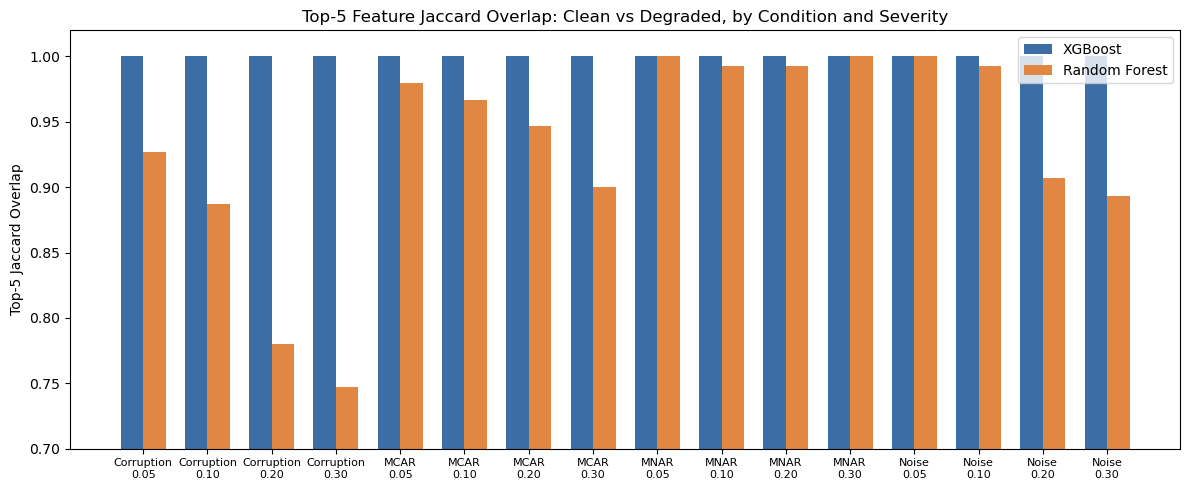

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Condition-severity labels
conditions = ['Corruption\n0.05', 'Corruption\n0.10', 'Corruption\n0.20', 'Corruption\n0.30',
              'MCAR\n0.05', 'MCAR\n0.10', 'MCAR\n0.20', 'MCAR\n0.30',
              'MNAR\n0.05', 'MNAR\n0.10', 'MNAR\n0.20', 'MNAR\n0.30',
              'Noise\n0.05', 'Noise\n0.10', 'Noise\n0.20', 'Noise\n0.30']

xgb_jaccard = [1.000, 1.000, 1.000, 1.000,
               1.000, 1.000, 1.000, 1.000,
               1.000, 1.000, 1.000, 1.000,
               1.000, 1.000, 1.000, 1.000]

rf_jaccard = [0.927, 0.887, 0.780, 0.747,
              0.980, 0.967, 0.947, 0.900,
              1.000, 0.993, 0.993, 1.000,
              1.000, 0.993, 0.907, 0.893]

x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, xgb_jaccard, width, label='XGBoost', color='#3B6EA5')
ax.bar(x + width/2, rf_jaccard, width, label='Random Forest', color='#E28743')

ax.set_ylabel('Top-5 Jaccard Overlap')
ax.set_ylim(0.7, 1.02)
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=8)
ax.legend()
ax.set_title('Top-5 Feature Jaccard Overlap: Clean vs Degraded, by Condition and Severity')
plt.tight_layout()
plt.savefig('results/jaccard_overlap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. XGBoost vs RF: comparison of explanation stability

For each degradation condition and severity level, the mean instance-level cosine similarity is compared between XGBoost and Random Forest. A bootstrap confidence interval is calculated for the difference in mean stability between the two models.

In [10]:
comparison_rows = []
for (condition_name, severity), group in results_raw.groupby(["condition", "severity"]):
    xgb_vals = group[group["model"] == "XGBoost"]["instance_cosine_mean"].values
    rf_vals = group[group["model"] == "RandomForest"]["instance_cosine_mean"].values
    if len(xgb_vals) == 0 or len(rf_vals) == 0:
        continue
    diff = bootstrap_diff_ci(xgb_vals, rf_vals, random_state=BASE_SEED)
    comparison_rows.append({
        "condition": condition_name, "severity": severity,
        "xgb_mean": np.mean(xgb_vals), "rf_mean": np.mean(rf_vals),
        "mean_diff_xgb_minus_rf": diff["mean_diff"],
        "ci_lower": diff["ci_lower"], "ci_upper": diff["ci_upper"],
        "difference_significant": diff["excludes_zero"],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(["condition", "severity"]).reset_index(drop=True)
save_results(comparison_df, RESULTS_DIR, experiment_name="xgb_vs_rf_comparison",
             metadata={"metric": "instance_cosine_mean", "n_repeats": N_REPEATS})
comparison_df


,condition,severity,xgb_mean,rf_mean,mean_diff_xgb_minus_rf,ci_lower,ci_upper,difference_significant
0,Corruption,0.05,0.987397,0.992330,-0.004933,-0.007139,-0.002837,True
1,Corruption,0.10,0.973937,0.983256,-0.009319,-0.012133,-0.006571,True
2,Corruption,0.20,0.948353,0.966003,-0.017650,-0.022986,-0.012388,True
3,Corruption,0.30,0.926716,0.954477,-0.027761,-0.033045,-0.022381,True
4,MCAR,0.05,0.960844,0.957845,0.003000,-0.003314,0.008992,False
5,MCAR,0.10,0.924039,0.920100,0.003938,-0.003911,0.011521,False
6,MCAR,0.20,0.847911,0.844228,0.003683,-0.006643,0.013778,False
7,MCAR,0.30,0.770532,0.772850,-0.002318,-0.013109,0.008215,False
8,MNAR,0.05,0.976635,0.979444,-0.002809,-0.007898,0.002509,False
9,MNAR,0.10,0.969951,0.973238,-0.003287,-0.009878,0.003306,False


## 8. Plots: stability vs. degradation severity

One figure per degradation type, comparing XGBoost vs RF, with 95% CI
shading.

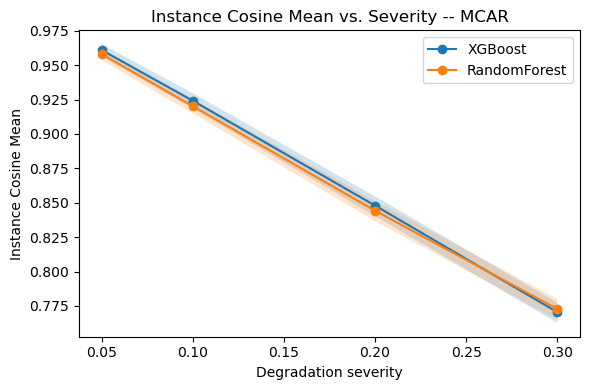

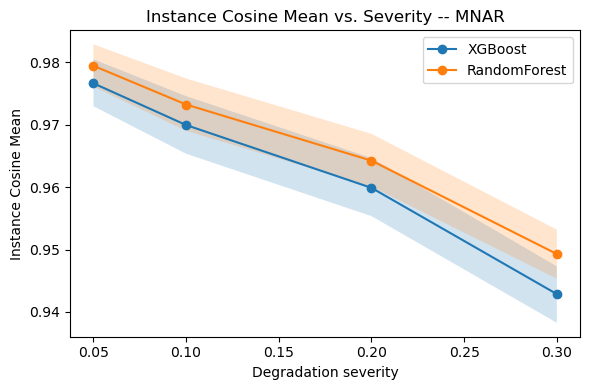

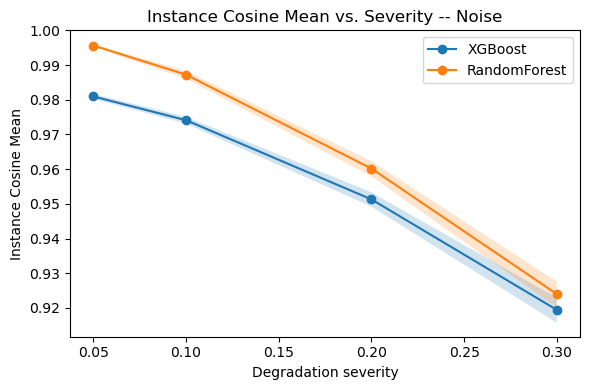

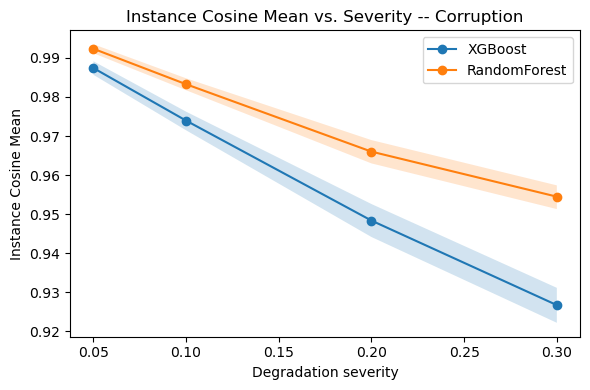

In [11]:
import matplotlib.pyplot as plt

def plot_metric_vs_severity(summary_df, condition_name, metric="instance_cosine_mean"):
    fig, ax = plt.subplots(figsize=(6, 4))
    for model_name in MODELS:
        sub = summary_df[(summary_df["model"] == model_name) & (summary_df["condition"] == condition_name)]
        sub = sub.sort_values("severity")
        ax.plot(sub["severity"], sub[f"{metric}_mean"], marker="o", label=model_name)
        ax.fill_between(sub["severity"], sub[f"{metric}_ci_lower"], sub[f"{metric}_ci_upper"], alpha=0.2)
    ax.set_xlabel("Degradation severity")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_title(f"{metric.replace('_', ' ').title()} vs. Severity -- {condition_name}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/plot_{condition_name}_{metric}.png", dpi=150)
    plt.show()

for condition_name in ["MCAR", "MNAR", "Noise", "Corruption"]:
    plot_metric_vs_severity(summary_df, condition_name, metric="instance_cosine_mean")
